# Data Analysis 2 Hw2

In [1]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import *
from skimpy import skim
from stargazer.stargazer import Stargazer

%matplotlib inline
warnings.filterwarnings("ignore")

### Load and prepare datasets

In [2]:

hotels_europe_price = pd.read_csv("https://osf.io/p6tyr/download")
hotels_europe_features = pd.read_csv("https://osf.io/utwjs/download")

# hotels_europe_price = pd.read_csv("hotels-europe_price (1).csv")
# hotels_europe_features = pd.read_csv("hotels-europe_features (1).csv")



In [3]:
# join datasets
europe = hotels_europe_price.merge(hotels_europe_features, on = "hotel_id")
europe.head()

,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,1,172,0,0% no offer,2017,11,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
1,1,122,1,15-50% offer,2018,1,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
2,1,122,1,15-50% offer,2017,12,0,1,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
3,1,552,1,1-15% offer,2017,12,0,1,4,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
4,1,122,1,15-50% offer,2018,2,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel


In [4]:
# create new binary variable
europe["highly_rated"] = np.where(europe["rating"] >= 4, 1, 0)
europe.head(10)

# filter the city: Salzburg
salzburg = (
    europe.loc[lambda x: x["accommodation_type"] == "Hotel"]
    .loc[lambda x: x["city_actual"] == "Salzburg"]
    .loc[lambda x: x["stars"].notnull()]
)

salzburg


,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type,highly_rated
127748,20151,164,1,1-15% offer,2018,2,1,0,1,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127749,20151,173,0,0% no offer,2017,11,0,0,1,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127750,20151,733,0,0% no offer,2017,12,0,1,4,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127751,20152,2047,0,0% no offer,2017,12,0,1,4,0,...,Salzburg,107.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,1018.0,50.0,Hotel,1
127752,20152,319,1,15-50% offer,2017,11,0,0,1,1,...,Salzburg,107.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,1018.0,50.0,Hotel,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129150,20427,61,1,50%-75% offer,2017,11,0,0,1,1,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129151,20427,489,1,1-15% offer,2017,12,0,1,4,1,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129152,20427,88,1,15-50% offer,2018,6,1,0,1,0,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129153,20427,91,1,15-50% offer,2018,5,1,0,1,0,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0


### Data Cleaning

In [5]:
# Drop any duplicates
salzburg_clean = salzburg.drop_duplicates()
salzburg_clean.shape

(564, 25)

In [6]:
# Check for missing values
salzburg_clean.isna().sum()

hotel_id              0
price                 0
offer                 0
offer_cat             0
year                  0
month                 0
weekend               0
holiday               0
nnights               0
scarce_room           0
city                  0
distance              0
stars                 0
rating                0
country               0
city_actual           0
rating_reviewcount    0
center1label          0
center2label          0
neighbourhood         0
ratingta              0
ratingta_count        0
distance_alter        0
accommodation_type    0
highly_rated          0
dtype: int64

In [7]:
# Filter columns to only necessary variables 
salzburg_clean = salzburg_clean[["hotel_id", "highly_rated", "price","distance","rating_reviewcount"]]
salzburg_clean.head(5)

,hotel_id,highly_rated,price,distance,rating_reviewcount
127748,20151,1,164,0.6,61.0
127749,20151,1,173,0.6,61.0
127750,20151,1,733,0.6,61.0
127751,20152,1,2047,0.3,107.0
127752,20152,1,319,0.3,107.0


# Examining Relationships 

Between high rating and other accomodation features

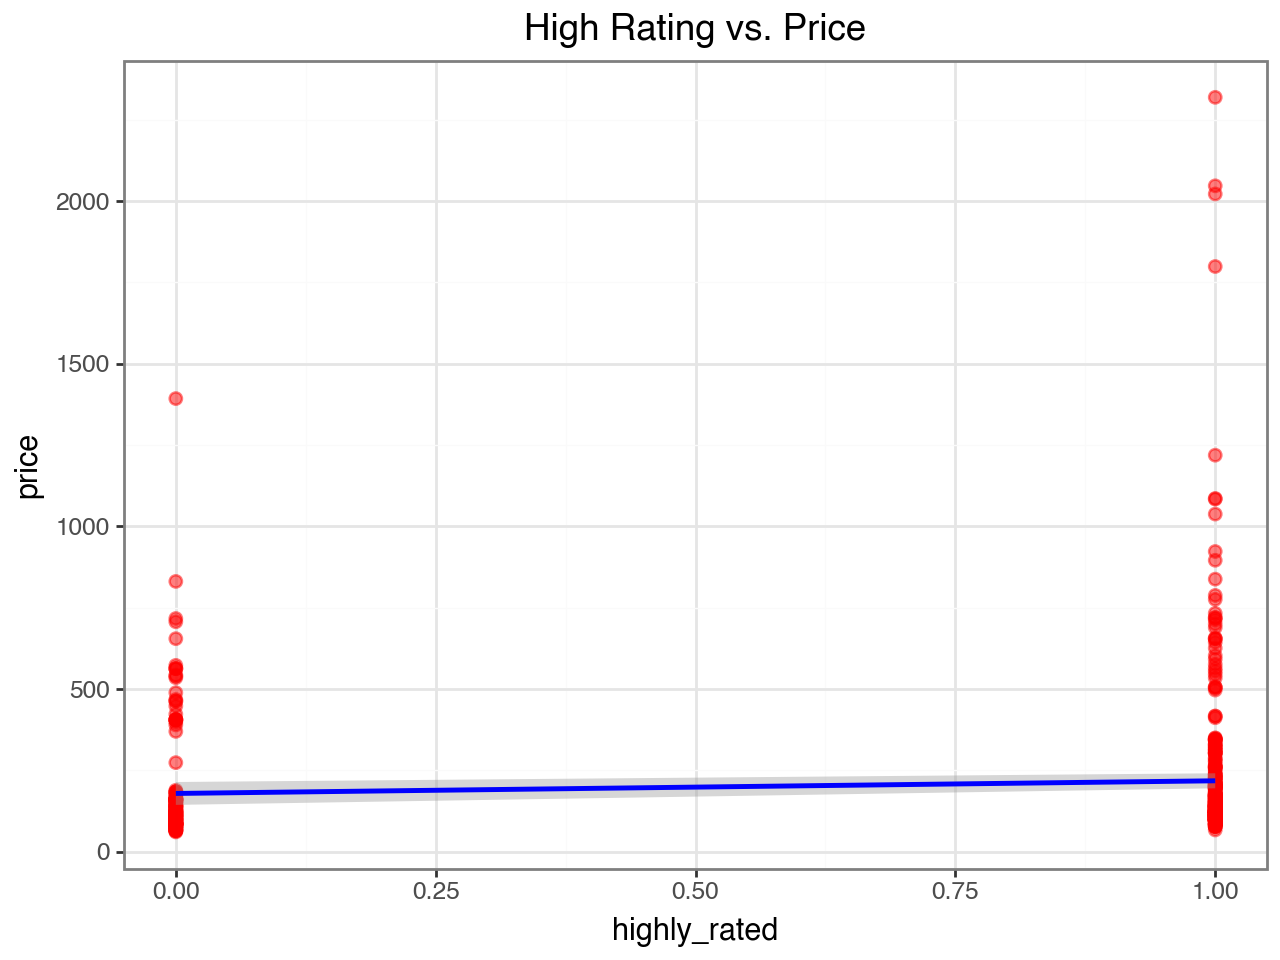

In [10]:
# Rating and Price
p1 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="highly_rated", y="price"), color="red", size=2, alpha=0.5)
    + labs(x="highly_rated", y="price")
    + theme_bw()
    + geom_smooth(aes(x="highly_rated", y="price"),method="lm",color="blue",formula="y~x")
    + labs(title= "High Rating vs. Price")
    )
p1

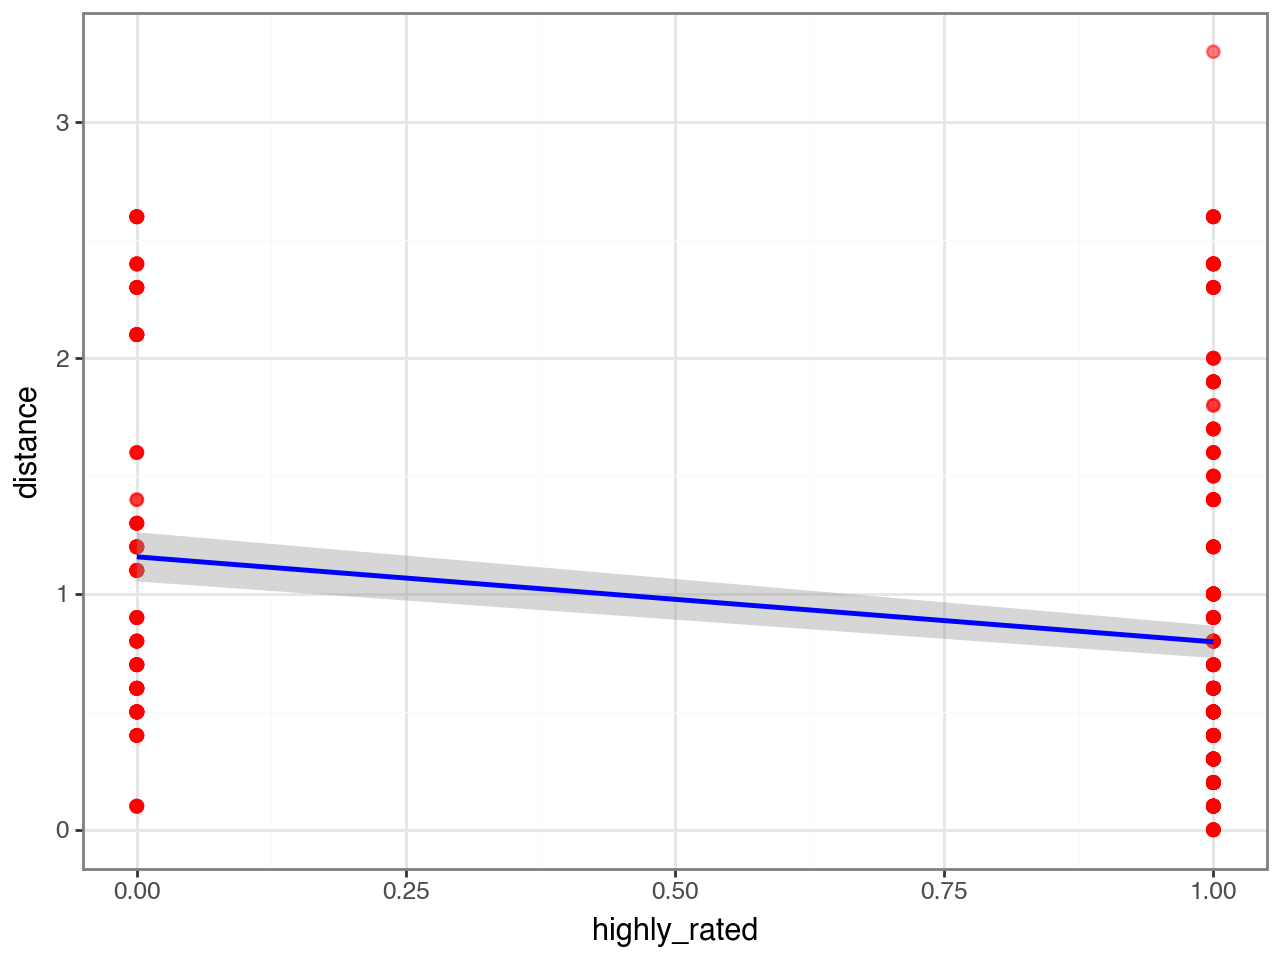

In [ ]:
# Rating and distance
p2 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="highly_rated", y="distance"), color="red", size=2, alpha=0.5)
    + labs(x="highly_rated", y="distance")
    + theme_bw()
    + geom_smooth(aes(x="highly_rated", y="distance"),method="lm",color="blue",formula="y~x")
    + labs(title= "High Rating vs. Distance")
    )
p2

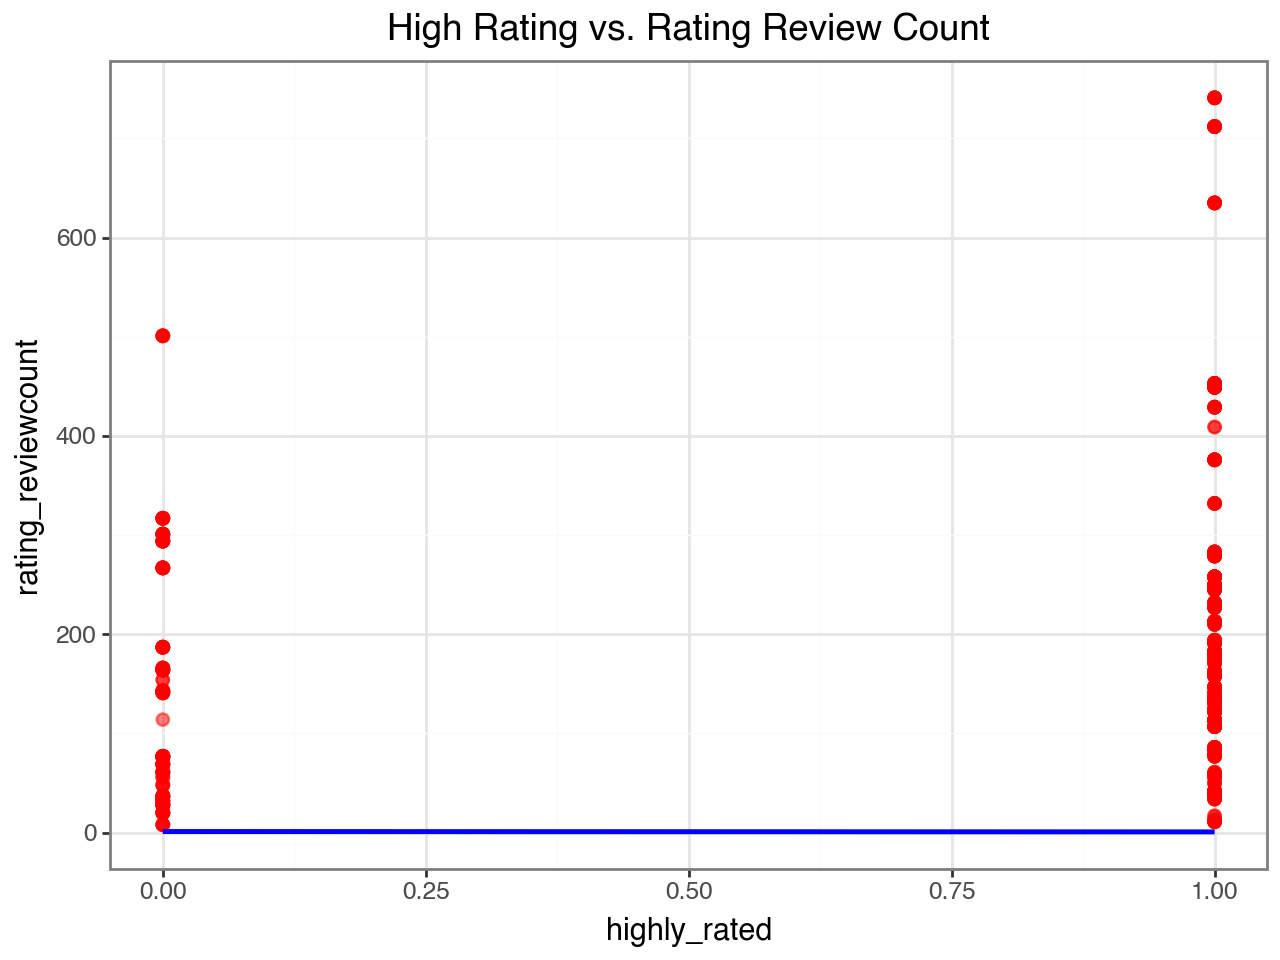

In [18]:
# Rating and Rating Review Count
p3 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="highly_rated", y="rating_reviewcount"), color="red", size=2, alpha=0.5)
    + labs(x="highly_rated", y="rating_reviewcount")
    + theme_bw()
    + geom_smooth(aes(x="highly_rated", y="distance"),method="lm",color="blue",formula="y~x")
    + labs(title= "High Rating vs. Rating Review Count")
    )
p3

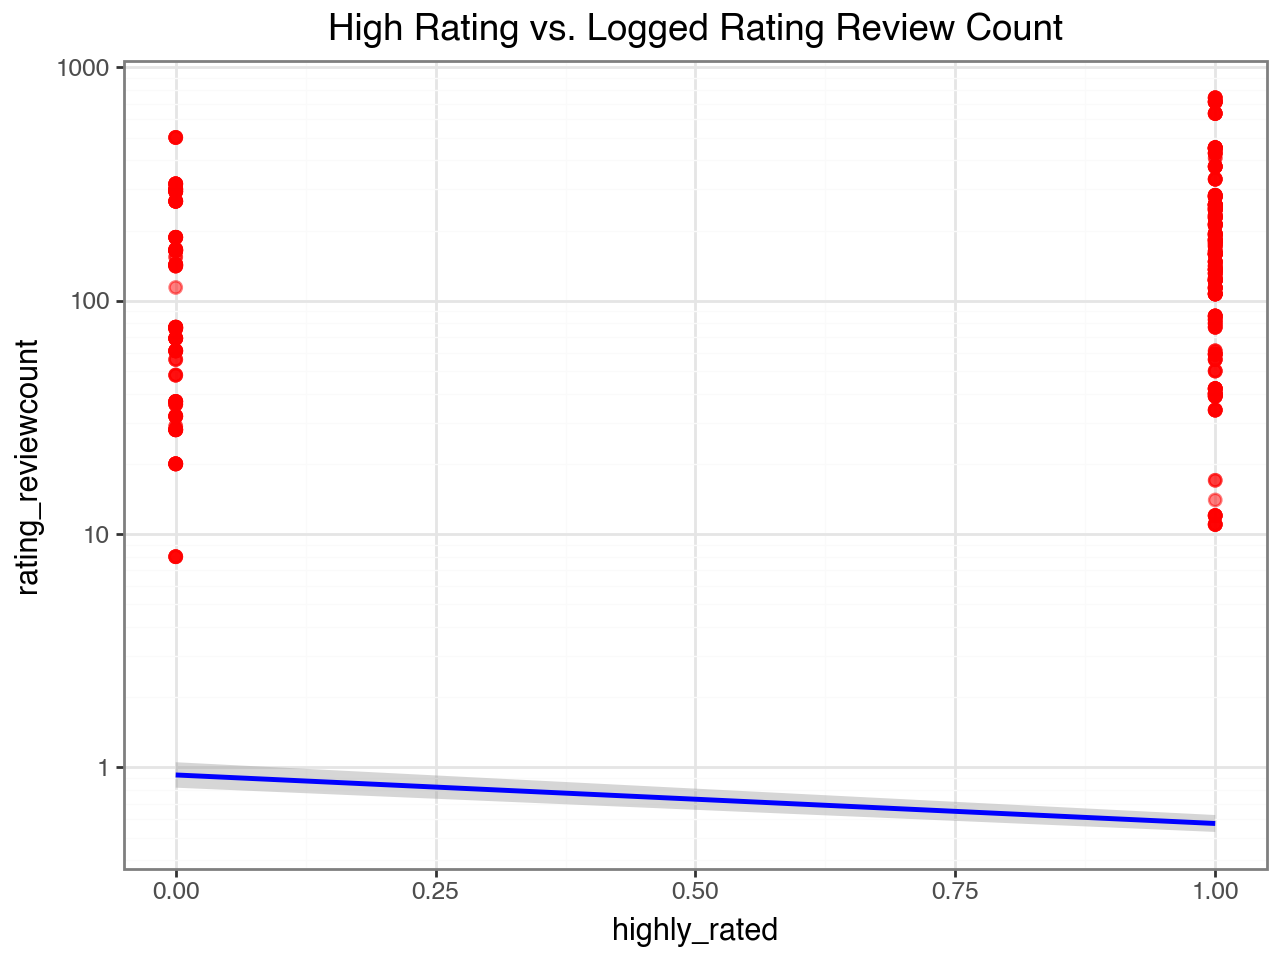

In [17]:
# Rating and Log Rating Review Count
p4 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="highly_rated", y="rating_reviewcount"), color="red", size=2, alpha=0.5)
    + labs(x="highly_rated", y="rating_reviewcount")
    + theme_bw()
    + geom_smooth(aes(x="highly_rated", y="distance"),method="lm",color="blue",formula="y~x")
    + labs(title= "High Rating vs. Logged Rating Review Count")
    + scale_y_log10()
    )
p4